**Feature-to-feature correlations** | Detect strongly related predictors such as `lcd` and `pld` | `lcd` and `suraface-area`

In [12]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt  
from pandas.plotting import scatter_matrix
import seaborn as sns


In [6]:
data = pd.read_csv('/home/susan/mof-co2-adsorption/data/processed/data_clean_v2')
df = data.copy()
df.columns

Index(['filename', 'lcd', 'pld', 'void_fraction', 'surface_area_m2g', 'mofid',
       'CO2_uptake_0.01bar_molkg', 'CO2_uptake_0.05bar_molkg',
       'CO2_uptake_0.1bar_molkg', 'CO2_uptake_0.5bar_molkg',
       'CO2_uptake_2.5bar_molkg'],
      dtype='object')

In [25]:
# Calculate the Pearson correlation between LCD and PLD.
correlation_lcd_pld = df['lcd'].corr(df['pld'])

# Display the LCD–PLD correlation.
print(f'LCD–PLD correlation: {correlation_lcd_pld:.2f}')
print('=' * 30)

# Calculate the Pearson correlation between LCD and surface area.
correlation_lcd_surface = df['lcd'].corr(df['surface_area_m2g'])

# Display the LCD–surface area correlation.
print(f'LCD–surface area correlation: {correlation_lcd_surface:.2f}')
print('=' * 30)

# Calculate the Pearson correlation between PLD and surface area.
correlation_pld_surface = df['pld'].corr(df['surface_area_m2g'])

# Display the PLD–surface area correlation.
print(f'PLD–surface area correlation: {correlation_pld_surface:.2f}')
print('=' * 30)
# Calculate the Pearson correlation between void fraction and LCD.
correlation_void_lcd = df['void_fraction'].corr(df['lcd'])

# Display the correlation rounded to two decimal places.
print(f'Void fraction–LCD correlation: {correlation_void_lcd:.2f}')
print('=' * 30)
# Calculate the Pearson correlation between void fraction and LCD.
correlation_void_pld = df['void_fraction'].corr(df['pld'])

# Display the correlation rounded to two decimal places.
print(f'Void fraction–PLD correlation: {correlation_void_pld:.2f}')
print('=' * 30)

correlation_void_surface = df['void_fraction'].corr(df['surface_area_m2g'])

# Display the correlation rounded to two decimal places.
print(f'Void fraction–Surface correlation: {correlation_void_surface:.2f}')

LCD–PLD correlation: 0.98
LCD–surface area correlation: 0.82
PLD–surface area correlation: 0.79
Void fraction–LCD correlation: 0.82
Void fraction–PLD correlation: 0.80
Void fraction–Surface correlation: 0.90


==============================================
## Feature-to-Feature Correlation

* LCD and PLD have a very strong positive correlation of approximately 0.98. 
This means that MOFs with larger cavity diameters generally also have larger 
pore-limiting diameters.

* Surface area also has a strong positive correlation of approximately 0.82 
with LCD and PLD. This indicates that MOFs with larger pore dimensions 
generally have higher surface areas.

* The very strong correlation between LCD and PLD suggests that these two 
features contain similar information and may cause multicollinearity in 
linear regression models.

* Void fraction has strong positive correlations with LCD (0.82) and PLD (0.80). 
It has an even stronger positive correlation with surface area (0.90).This means that MOFs with larger pore dimensions generally have greater empty pore volume and higher surface area. Among these relationships, void fraction 
is most strongly related to surface area.

## Modeling Implications

- The correlation analysis shows that several structural predictors contain
overlapping information. In particular, LCD and PLD are highly correlated
(0.98), which may cause multicollinearity in linear regression models.

- All four predictors will initially be included in the models. Model performance
will then be compared after removing either LCD or PLD. If the prediction
results remain similar, the simpler feature set will be selected.

- Because feature importance may change with pressure, this comparison will be
performed separately for each CO₂ uptake target.

==================================================================================


In [ ]:
#Step 1 — Select the predictor features
# Store the four predictor column names in a list.
feature_columns = ['lcd', 'pld', 'void_fraction', 'surface_area_m2g']

# Create a DataFrame containing only the predictor features.
features_df = df[feature_columns]
# Display the first five rows of the selected features.
features_df.head()


,lcd,pld,void_fraction,surface_area_m2g
0,11.75,10.75,0.795539,3676.3
1,4.75,3.25,0.388986,580.7
2,4.75,3.75,0.307505,377.6
3,9.25,8.25,0.731919,3399.2
4,3.75,2.75,0.323803,85.2


In [31]:
# Step 2 — Sample the data for visualization
# Randomly select 2,000 rows to make the scatter matrix readable.
features_sample = features_df.sample(n=2000, random_state=42)
# Display the number of rows and columns in the sample.
features_sample.shape

(2000, 4)

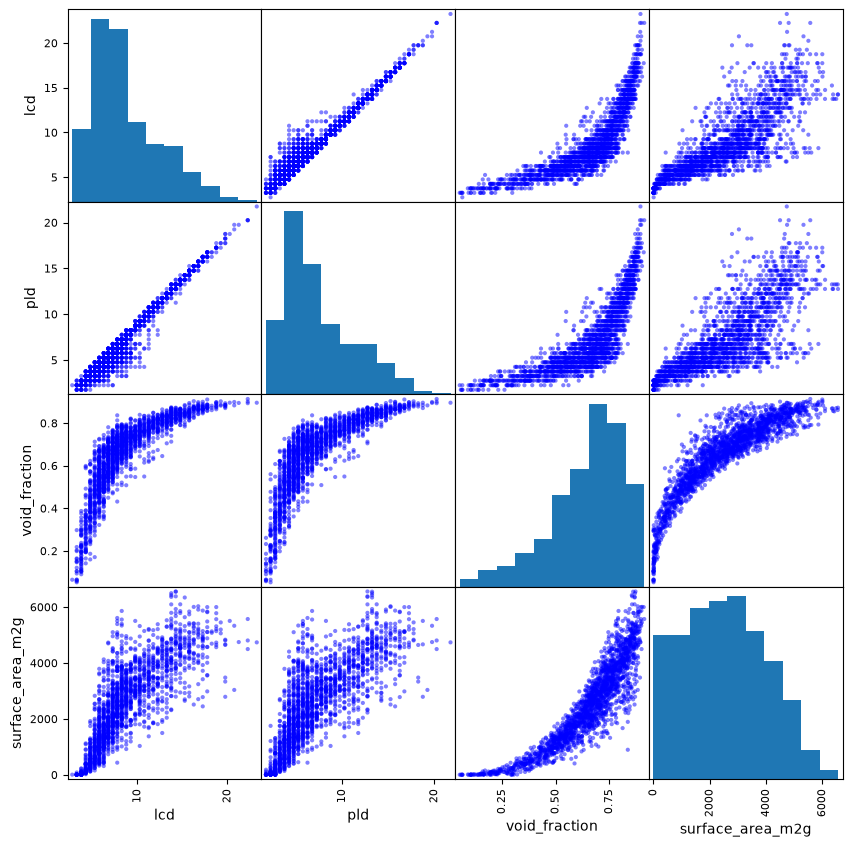

In [32]:
# plotting.scatter_matrix() method is used to create a scatter matrix plot of the DataFrame.
# It takes the DataFrame as input and creates a grid of scatter plots for each pair of columns in the DataFrame.
# The diagonal of the scatter matrix shows the distribution of each column, while the off-diagonal plots show the relationship between pairs of columns.

scatter_matrix(features_sample, figsize=(10, 10), diagonal='hist', alpha=0.5, color='blue')
plt.savefig("scatter_matrix.png", dpi=150, bbox_inches="tight")  #
plt.show()


## Scatter Matrix Interpretation

- The scatter matrix confirms strong positive relationships among the four
structural features. LCD and PLD show an almost linear relationship, supporting
their very strong correlation of 0.98 and indicating that they contain similar
information.

- Void fraction increases nonlinearly with LCD and PLD. Surface area also shows
a strong nonlinear increase with void fraction. Surface area generally rises
with pore diameter, although the wider spread of points indicates that pore
diameter does not fully determine surface area.

- These results show that several predictors are strongly related and that some
relationships are nonlinear. During modeling, LCD and PLD may cause
multicollinearity in linear regression. Nonlinear models may also represent
these curved relationships better.